# Train Classifier

In [ ]:
# Install specific versions
!pip install -q lightgbm scikit-learn==1.8.0

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import os
import gc # Garbage collector to save RAM

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Paths
BASE_PATH = '/content/drive/MyDrive/imdb_data/ekko_artifacts'
RATINGS_PATH = f'{BASE_PATH}/ratings_labeled.parquet'
EMBEDDINGS_PATH = f'{BASE_PATH}/ai_embeddings.npy'
METADATA_PATH = f'{BASE_PATH}/metadata_enriched.parquet'
OUTPUT_DIR = f'{BASE_PATH}/models'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Environment Ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 58.7 MB/s eta 0:00:00
Mounted at /content/drive
Environment Ready.


In [ ]:
print("Loading data...")
# Load Ratings (Target)
df_ratings = pd.read_parquet(RATINGS_PATH)

# Load ai Embeddings (Features)
# Mmap_mode='r' allows us to read this huge file from disk without exploding RAM
ai_emb = np.load(EMBEDDINGS_PATH, mmap_mode='r')

# Load Metadata (To map tconst -> index)
df_meta = pd.read_parquet(METADATA_PATH)

# Create a map: tconst -> integer index (0 to 400k)
# We need this to look up the correct embedding row for each movie
tconst_to_idx = {tconst: idx for idx, tconst in enumerate(df_meta['tconst'])}

# Filter ratings to only include items we have embeddings for
df_ratings = df_ratings[df_ratings['tconst'].isin(tconst_to_idx)].copy()
df_ratings['item_idx'] = df_ratings['tconst'].map(tconst_to_idx)

print(f"Data Loaded. Ratings: {len(df_ratings)}")
print(f"Embeddings Shape: {ai_emb.shape}")

Loading data...
Data Loaded. Ratings: 25716187
Embeddings Shape: (428167, 768)


In [ ]:
from scipy.sparse import coo_matrix

print("Building Interaction Matrix...")
# Map Users to Int IDs
user_ids = df_ratings['userID'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
df_ratings['user_idx'] = df_ratings['userID'].map(user_to_idx)

# Create Sparse Matrix
R = coo_matrix(
    (df_ratings['target'], (df_ratings['user_idx'], df_ratings['item_idx'])),
    shape=(len(user_ids), ai_emb.shape[0])
)

print("Training SVD (Collaborative Signal)...")
# Train TruncatedSVD (Fast Matrix Factorization)
svd = TruncatedSVD(n_components=32, random_state=42)
user_factors = svd.fit_transform(R)
item_factors = svd.components_.T

print("SVD Trained. We will use dot product as a feature.")

Building Interaction Matrix...
Training SVD (Collaborative Signal)...
SVD Trained. We will use dot product as a feature.


### BEFORE TUNING THE MODEL

In [ ]:
# Cell 4: Fast Vectorized Feature Engineering (Optimized)

print("Splitting Data...")
# Split
train_df, test_df = train_test_split(df_ratings, test_size=0.2, random_state=42, stratify=df_ratings['target'])

# HELPER: Build User Profiles (The "ai Vector" for each user)
print("Building User ai Profiles (Matrix Mode)...")

EMBEDDING_DIM = ai_emb.shape[1]
print(f"Detected Embedding Dimension: {EMBEDDING_DIM}")

# Convert User Profiles to a Dense Matrix for fast lookup
# Find max user ID to size the matrix correctly
max_user_id = df_ratings['user_idx'].max()
user_profile_matrix = np.zeros((max_user_id + 1, EMBEDDING_DIM), dtype=np.float32)

# Select POSITIVE interactions (Likes) from Train
likes = train_df[train_df['target'] == 1]

# GroupBy is much faster than iterating
print("Grouping user likes...")
user_groups = likes.groupby('user_idx')['item_idx'].apply(list)

print("Averaging embeddings (this takes ~1-2 mins)...")
# We iterate only over unique users (200k), not all ratings (29M)
for u_idx, item_indices in user_groups.items():
    # Fast numpy average
    # We grab all vectors for this user at once
    vectors = ai_emb[item_indices]
    user_profile_matrix[u_idx] = np.mean(vectors, axis=0)

print(f"User Profile Matrix Built: {user_profile_matrix.shape}")

# FAST FEATURE GENERATION (BATCHED)
def build_features_fast(df_subset, batch_size=100000):
    features_list = []
    targets_list = []

    # Pre-convert columns to numpy arrays
    u_indices_all = df_subset['user_idx'].values
    i_indices_all = df_subset['item_idx'].values
    y_values_all = df_subset['target'].values

    total_rows = len(df_subset)
    print(f"Processing {total_rows} rows in batches of {batch_size}...")

    for start in range(0, total_rows, batch_size):
        end = min(start + batch_size, total_rows)

        # Get Batch Indices
        batch_u = u_indices_all[start:end]
        batch_i = i_indices_all[start:end]

        # Gather Vectors (Fast Lookup)
        # User vectors from our new profile matrix
        u_vecs = user_profile_matrix[batch_u]
        # Item vectors from ai embedding file
        i_vecs = ai_emb[batch_i]

        # Compute Dot Products (Vectorized)
        # axis=1 means "sum across the columns" -> result is array of scores
        sim_ai = np.sum(u_vecs * i_vecs, axis=1)

        # SVD Scores (Vectorized)
        u_factors = user_factors[batch_u]
        i_factors = item_factors[batch_i]
        score_svd = np.sum(u_factors * i_factors, axis=1)

        # Stack into shape (Batch_Size, 2)
        batch_features = np.column_stack((sim_ai, score_svd))

        features_list.append(batch_features)
        targets_list.append(y_values_all[start:end])

        if start % (batch_size * 10) == 0:
            print(f"  Done {start}/{total_rows}...")

    # Concatenate all batches
    return np.vstack(features_list), np.concatenate(targets_list)

print("Generating Training Features (Fast)...")
X_train, y_train = build_features_fast(train_df)

print("Generating Test Features (Fast)...")
X_test, y_test = build_features_fast(test_df)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Splitting Data...
Building User ai Profiles (Matrix Mode)...
Detected Embedding Dimension: 768
Grouping user likes...
Averaging embeddings (this takes ~1-2 mins)...
User Profile Matrix Built: (200937, 768)
Generating Training Features (Fast)...
Processing 20572949 rows in batches of 100000...
  Done 0/20572949...
  Done 1000000/20572949...
  Done 2000000/20572949...
  Done 3000000/20572949...
  Done 4000000/20572949...
  Done 5000000/20572949...
  Done 6000000/20572949...
  Done 7000000/20572949...
  Done 8000000/20572949...
  Done 9000000/20572949...
  Done 10000000/20572949...
  Done 11000000/20572949...
  Done 12000000/20572949...
  Done 13000000/20572949...
  Done 14000000/20572949...
  Done 15000000/20572949...
  Done 16000000/20572949...
  Done 17000000/20572949...
  Done 18000000/20572949...
  Done 19000000/20572949...
  Done 20000000/20572949...
Generating Test Features (Fast)...
Processing 5143238 rows in batches of 100000...
  Done 0/5143238...
  Done 1000000/5143238...
  Don

Training LightGBM Classifier...
[LightGBM] [Info] Number of positive: 16040979, number of negative: 4531970
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.815370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 20572949, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.779712 -> initscore=1.263990
[LightGBM] [Info] Start training from score 1.263990
Training Complete!
ROC AUC: 0.7931
Accuracy: 0.8025

Feature Importance:
ai_similarity: 1628
svd_score: 1372


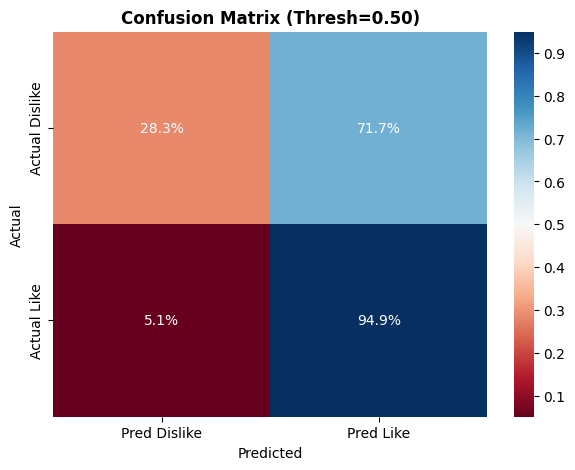

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

print("Training LightGBM Classifier...")

feature_names = ['ai_similarity', 'svd_score']
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Initialize
clf = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42
)

# Fit (using the named DataFrame)
clf.fit(X_train_df, y_train)

# Evaluate
y_pred_prob = clf.predict_proba(X_test_df)[:, 1]

best_thresh = 0.5
preds = (y_pred_prob > best_thresh).astype(int)

auc = roc_auc_score(y_test, y_pred_prob)
acc = accuracy_score(y_test, preds)

print(f"Training Complete!")
print(f"ROC AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}\n")

# Feature Importance
print("Feature Importance:")
for name, importance in zip(clf.feature_name_, clf.feature_importances_):
    print(f"{name}: {importance}")

# Visualize Confusion Matrix
plt.figure(figsize=(7, 5)) # Setup the figure size
cm = confusion_matrix(y_test, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdBu',
            xticklabels=['Pred Dislike', 'Pred Like'],
            yticklabels=['Actual Dislike', 'Actual Like'])
plt.title(f'Confusion Matrix (Thresh={best_thresh:.2f})', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

we will check for the unbalancing data

In [ ]:
print('Value counts for target column:')
target_counts = df_ratings['target'].value_counts()
print(target_counts)
print('\nPercentage of each target class:')
print(target_counts / len(df_ratings) * 100)

Value counts for target column:
target
1    20051224
0     5664963
Name: count, dtype: int64

Percentage of each target class:
target
1    77.971217
0    22.028783
Name: count, dtype: float64


In the next cell we will fix the 0.5 threshold to see if it works.


EKKO PRODUCTION MODEL AUDIT
Optimal 'Fair' Threshold: 0.7758 (Maximizes Balanced Accuracy)

PERFORMANCE REPORT
------------------------------
Recall (Like):         0.6841  (Captures 68.4% of good movies)
Specificity (Dislike): 0.7487  (Filters 74.9% of bad movies)
Precision (Like):      0.9060  (Trustworthiness of 'Like')
Balanced Accuracy:     0.7164
ROC AUC Score:         0.7931

CAROUSEL QUALITY (Precision @ Top K)
------------------------------
Top 1% (Hero Banner):  99.88% accurate (Size: 51432)
Top 5% (Recs Feed):    99.52% accurate (Size: 257161)


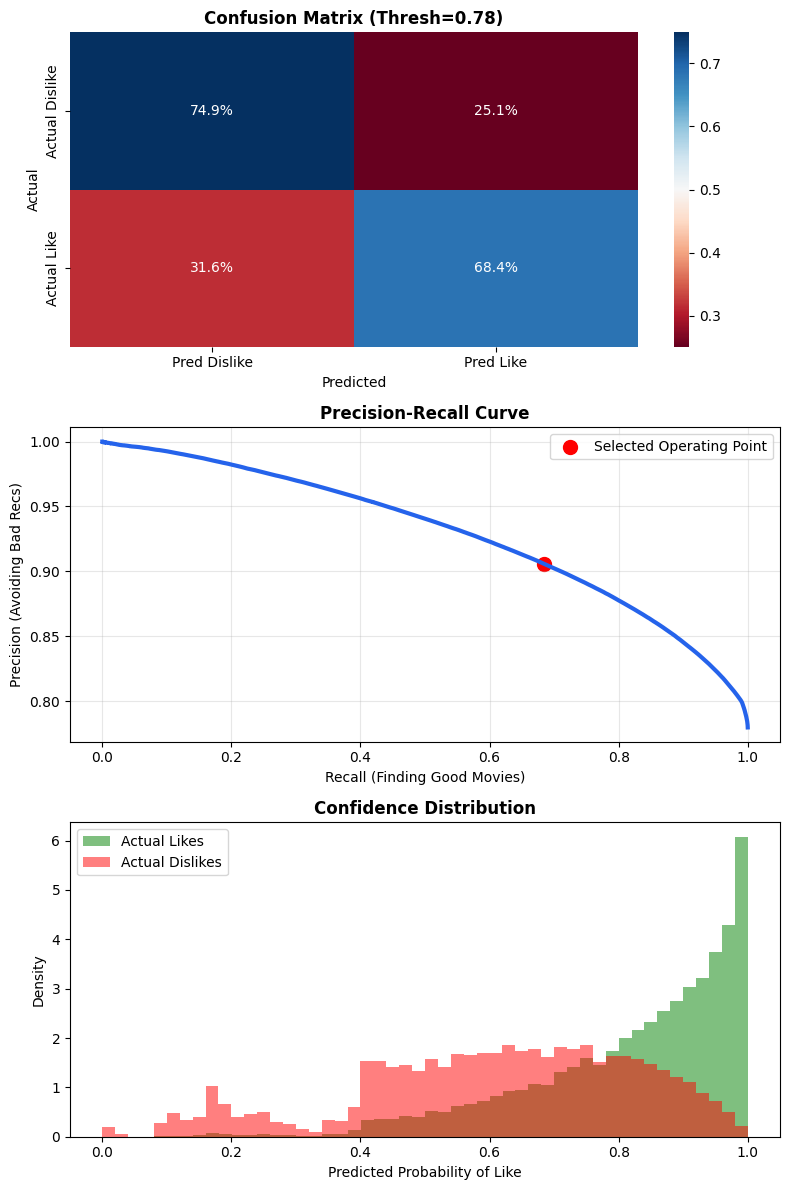

In [ ]:
# The Master Evaluation

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    balanced_accuracy_score
)

FEATURE_NAMES = ['ai_similarity', 'svd_score']

def calculate_top_k_precision(y_true, probs, k_percent=5):
    """
    Calculates Precision at Top K% of predictions.
    This answers: "When the model is most confident, is it right?"
    """
    df_eval = pd.DataFrame({'target': y_true, 'prob': probs})
    df_eval = df_eval.sort_values(by='prob', ascending=False)
    top_k_count = int(len(df_eval) * (k_percent / 100))
    top_k_df = df_eval.head(top_k_count)
    return top_k_df['target'].mean(), top_k_count

def evaluate_production_model(model, X_array, y):
    print(f"\n{'='*50}")
    print(f"EKKO PRODUCTION MODEL AUDIT")
    print(f"{'='*50}")

    X_df = pd.DataFrame(X_array, columns=FEATURE_NAMES)
    probs = model.predict_proba(X_df)[:, 1]

    # FIND OPTIMAL THRESHOLD (Youden's J Statistic)
    # We maximize (Recall + Specificity) to treat Dislikes fairly.
    # This fixes the "Positivity Bias" issue.
    fpr, tpr, thresholds = roc_curve(y, probs)
    J = tpr - fpr  # J = Sensitivity + Specificity - 1
    best_idx = np.argmax(J)
    best_thresh = thresholds[best_idx]

    print(f"Optimal 'Fair' Threshold: {best_thresh:.4f} (Maximizes Balanced Accuracy)")

    # APPLY THRESHOLD
    preds = (probs >= best_thresh).astype(int)

    # CORE METRICS
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp) # True Negative Rate
    recall = tp / (tp + fn)      # True Positive Rate
    precision = tp / (tp + fp)   # Positive Predictive Value

    print(f"\nPERFORMANCE REPORT")
    print(f"{'-'*30}")
    print(f"Recall (Like):         {recall:.4f}  (Captures {recall:.1%} of good movies)")
    print(f"Specificity (Dislike): {specificity:.4f}  (Filters {specificity:.1%} of bad movies)")
    print(f"Precision (Like):      {precision:.4f}  (Trustworthiness of 'Like')")
    print(f"Balanced Accuracy:     {(recall + specificity)/2:.4f}")
    print(f"ROC AUC Score:         {roc_auc_score(y, probs):.4f}")

    # RANKING QUALITY (Top-K)
    print(f"\nCAROUSEL QUALITY (Precision @ Top K)")
    print(f"{'-'*30}")
    p_at_1, count_1 = calculate_top_k_precision(y, probs, k_percent=1)
    p_at_5, count_5 = calculate_top_k_precision(y, probs, k_percent=5)
    print(f"Top 1% (Hero Banner):  {p_at_1:.2%} accurate (Size: {count_1})")
    print(f"Top 5% (Recs Feed):    {p_at_5:.2%} accurate (Size: {count_5})")

    # VISUALIZATIONS
    plt.figure(figsize=(8, 12))

    # Plot A: Confusion Matrix (The Truth)
    plt.subplot(3, 1, 1)
    cm = confusion_matrix(y, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdBu',
                xticklabels=['Pred Dislike', 'Pred Like'],
                yticklabels=['Actual Dislike', 'Actual Like'])
    plt.title(f'Confusion Matrix (Thresh={best_thresh:.2f})', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Plot B: Precision-Recall Curve
    plt.subplot(3, 1, 2)
    precisions_pr, recalls_pr, _ = precision_recall_curve(y, probs)
    plt.plot(recalls_pr, precisions_pr, color='#2563EB', lw=3)
    # Plot our chosen point
    # Find the recall on the PR curve closest to our actual recall
    idx_pr = (np.abs(recalls_pr - recall)).argmin()
    plt.scatter(recalls_pr[idx_pr], precisions_pr[idx_pr], color='red', s=100, label='Selected Operating Point')
    plt.title('Precision-Recall Curve', fontweight='bold')
    plt.xlabel('Recall (Finding Good Movies)')
    plt.ylabel('Precision (Avoiding Bad Recs)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot C: Probability Distribution
    plt.subplot(3, 1, 3)
    plt.hist(probs[y==1], bins=50, alpha=0.5, label='Actual Likes', color='green', density=True)
    plt.hist(probs[y==0], bins=50, alpha=0.5, label='Actual Dislikes', color='red', density=True)
    plt.title('Confidence Distribution', fontweight='bold')
    plt.xlabel('Predicted Probability of Like')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the Master Audit
evaluate_production_model(clf, X_test, y_test)

### AFTER TUNING THE MODEL

In [ ]:
# Cell 5: Train LightGBM (Aggressive Dislike Weighting)

print("Training LightGBM with DISLIKE PENALTY...")

# We define manual weights:
# Class 0 (Dislike): Weight 3.0 (Crucial to get right)
# Class 1 (Like):    Weight 1.0 (Standard)
# This forces the model to prioritize specificity.
custom_weights = {0: 3.0, 1: 1.0}

clf = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    class_weight=custom_weights # < The "Hammer"
)

# Fit
clf.fit(X_train, y_train)

# Evaluate
y_pred_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
acc = accuracy_score(y_test, (y_pred_prob > 0.5).astype(int))

print(f"Training Complete!")
print(f"ROC AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")

# Feature Importance
print("Feature Importance:")
print(f"ai Similarity: {clf.feature_importances_[0]}")
print(f"SVD Score:        {clf.feature_importances_[1]}")

In [ ]:
print("Saving Models...")

# Save SVD Item Factors (We need this in the App to calculate SVD scores)
# Shape: (Num_Items, 32)
np.save(f'{OUTPUT_DIR}/svd_item_factors.npy', item_factors)

# Save the tconst_to_idx map (Crucial for mapping ID -> Array Index)
joblib.dump(tconst_to_idx, f'{OUTPUT_DIR}/tconst_map.joblib')

print(f"Models saved to {OUTPUT_DIR}")

Saving Models...
Models saved to /content/drive/MyDrive/imdb_data/ekko_artifacts/models



 EKKO PRODUCTION MODEL AUDIT
 Optimal 'Fair' Threshold: 0.5410 (Maximizes Balanced Accuracy)

 PERFORMANCE REPORT
------------------------------
 Recall (Like):         0.6774  (Captures 67.7% of good movies)
 Specificity (Dislike): 0.7554  (Filters 75.5% of bad movies)
 Precision (Like):      0.9074  (Trustworthiness of 'Like')
 Balanced Accuracy:     0.7164
 ROC AUC Score:         0.7931

 CAROUSEL QUALITY (Precision @ Top K)
------------------------------
 Top 1% (Hero Banner):  99.87% accurate (Size: 51432)
 Top 5% (Recs Feed):    99.52% accurate (Size: 257161)


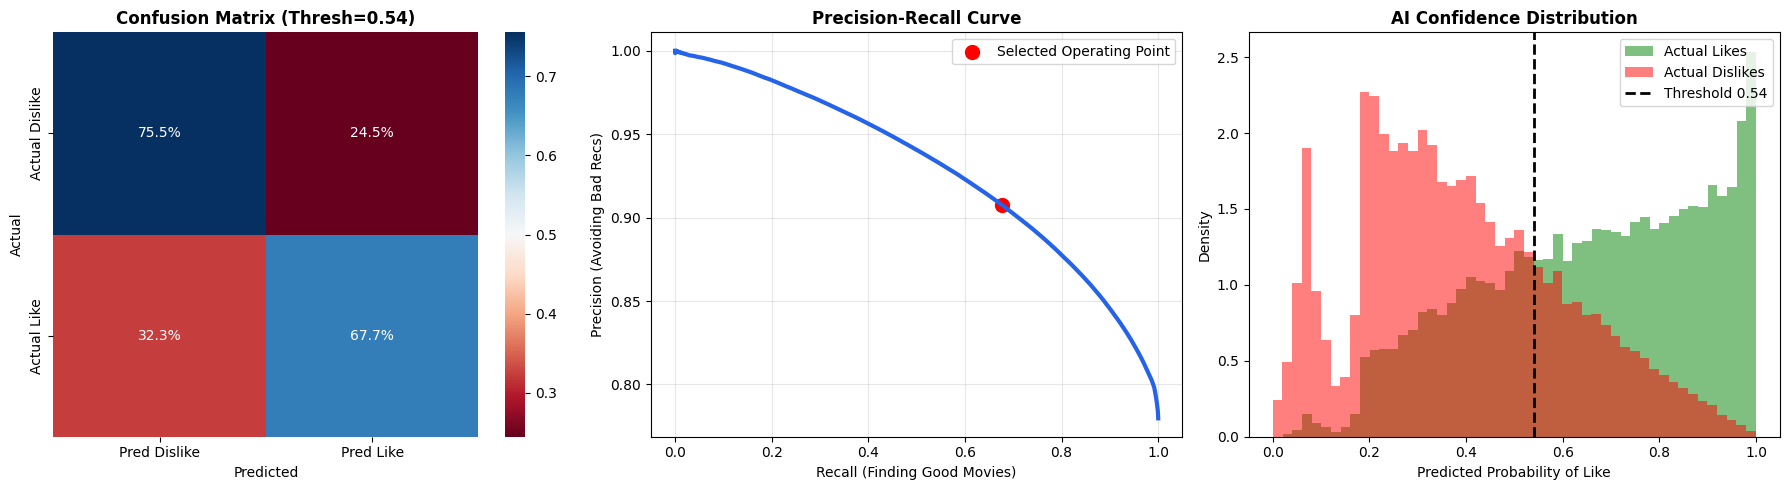

In [ ]:
# Cell 6: The Master Evaluation

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    balanced_accuracy_score
)

FEATURE_NAMES = ['ai_Sim', 'SVD_Score']

def calculate_top_k_precision(y_true, probs, k_percent=5):
    """
    Calculates Precision at Top K% of predictions.
    This answers: "When the model is most confident, is it right?"
    """
    df_eval = pd.DataFrame({'target': y_true, 'prob': probs})
    df_eval = df_eval.sort_values(by='prob', ascending=False)
    top_k_count = int(len(df_eval) * (k_percent / 100))
    top_k_df = df_eval.head(top_k_count)
    return top_k_df['target'].mean(), top_k_count

def evaluate_production_model(model, X_array, y):
    print(f"\n{'='*50}")
    print(f"EKKO PRODUCTION MODEL AUDIT")
    print(f"{'='*50}")

    X_df = pd.DataFrame(X_array, columns=FEATURE_NAMES)
    probs = model.predict_proba(X_df)[:, 1]

    # FIND OPTIMAL THRESHOLD (Youden's J Statistic)
    # We maximize (Recall + Specificity) to treat Dislikes fairly.
    # This fixes the "Positivity Bias" issue.
    fpr, tpr, thresholds = roc_curve(y, probs)
    J = tpr - fpr  # J = Sensitivity + Specificity - 1
    best_idx = np.argmax(J)
    best_thresh = thresholds[best_idx]

    print(f"Optimal 'Fair' Threshold: {best_thresh:.4f} (Maximizes Balanced Accuracy)")

    # APPLY THRESHOLD
    preds = (probs >= best_thresh).astype(int)

    # CORE METRICS
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp) # True Negative Rate
    recall = tp / (tp + fn)      # True Positive Rate
    precision = tp / (tp + fp)   # Positive Predictive Value

    print(f"\nPERFORMANCE REPORT")
    print(f"{'-'*30}")
    print(f"Recall (Like):         {recall:.4f}  (Captures {recall:.1%} of good movies)")
    print(f"Specificity (Dislike): {specificity:.4f}  (Filters {specificity:.1%} of bad movies)")
    print(f"Precision (Like):      {precision:.4f}  (Trustworthiness of 'Like')")
    print(f"Balanced Accuracy:     {(recall + specificity)/2:.4f}")
    print(f"ROC AUC Score:         {roc_auc_score(y, probs):.4f}")

    # RANKING QUALITY (Top-K)
    print(f"\nCAROUSEL QUALITY (Precision @ Top K)")
    print(f"{'-'*30}")
    p_at_1, count_1 = calculate_top_k_precision(y, probs, k_percent=1)
    p_at_5, count_5 = calculate_top_k_precision(y, probs, k_percent=5)
    print(f"Top 1% (Hero Banner):  {p_at_1:.2%} accurate (Size: {count_1})")
    print(f"Top 5% (Recs Feed):    {p_at_5:.2%} accurate (Size: {count_5})")

    # VISUALIZATIONS
    plt.figure(figsize=(18, 5))

    # Plot A: Confusion Matrix (The Truth)
    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdBu',
                xticklabels=['Pred Dislike', 'Pred Like'],
                yticklabels=['Actual Dislike', 'Actual Like'])
    plt.title(f'Confusion Matrix (Thresh={best_thresh:.2f})', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Plot B: Precision-Recall Curve
    plt.subplot(1, 3, 2)
    precisions_pr, recalls_pr, _ = precision_recall_curve(y, probs)
    plt.plot(recalls_pr, precisions_pr, color='#2563EB', lw=3)
    # Plot our chosen point
    # Find the recall on the PR curve closest to our actual recall
    idx_pr = (np.abs(recalls_pr - recall)).argmin()
    plt.scatter(recalls_pr[idx_pr], precisions_pr[idx_pr], color='red', s=100, label='Selected Operating Point')
    plt.title('Precision-Recall Curve', fontweight='bold')
    plt.xlabel('Recall (Finding Good Movies)')
    plt.ylabel('Precision (Avoiding Bad Recs)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot C: Probability Distribution
    plt.subplot(1, 3, 3)
    plt.hist(probs[y==1], bins=50, alpha=0.5, label='Actual Likes', color='green', density=True)
    plt.hist(probs[y==0], bins=50, alpha=0.5, label='Actual Dislikes', color='red', density=True)
    plt.title('Confidence Distribution', fontweight='bold')
    plt.xlabel('Predicted Probability of Like')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the Master Audit
evaluate_production_model(clf, X_test, y_test)

### Trying more fine tuning methods

In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.7 MB/s eta 0:00:00


In [ ]:
# Cell 7: Advanced Hyperparameter Tuning with Optuna (Fixed)

import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Define the Objective Function
def objective(trial):
    # Suggest hyperparameters
    param_grid = {
        'n_estimators': 100, # Keep fixed for tuning speed
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,

        # The Business Rule (Dictionary works here because we use LGBMClassifier)
        'class_weight': {0: 3.0, 1: 1.0},

        # Params to Tune
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    # Initialize the Scikit-Learn Wrapper (which understands the dict class_weight)
    model = lgb.LGBMClassifier(**param_grid)

    # Train
    model.fit(X_train, y_train)

    # Predict
    # Note: We must supply feature names via DataFrame to match the training format
    # But since we passed numpy arrays to fit(), we pass numpy arrays to predict()
    # to avoid overhead warnings.
    preds = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, preds)
    return auc

print(f"Starting Optuna Search (20 Trials)...")
print("-" * 40)

# Create Study
# We disable the extensive logging to keep your screen clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("-" * 40)
print(f"Best Trial Accuracy (AUC): {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

after 2 hours we got this:

Best Trial Accuracy (AUC): 0.7932

Best Hyperparameters:

    num_leaves: 26

    learning_rate: 0.10001382945629182

    reg_alpha: 0.20088051531284906

    reg_lambda: 2.328835722993535e-05

    subsample: 0.7986458120655612

    colsample_bytree: 0.5068692355785691

    min_child_samples: 51

Training Final Model with Optimized Hyperparameters...

EKKO PRODUCTION MODEL AUDIT
Optimal 'Fair' Threshold: 0.5315

PERFORMANCE REPORT
------------------------------
Recall (Like):         0.6852  (Captures 68.5% of good movies)
Specificity (Dislike): 0.7480  (Filters 74.8% of bad movies)
Precision (Like):      0.9059  (Trustworthiness: 90.6%)
Balanced Accuracy:     0.7166
ROC AUC Score:         0.7932

CAROUSEL QUALITY
------------------------------
Top 1% (Hero Banner):  99.88% accurate (Size: 51432)
Top 5% (Recs Feed):    99.53% accurate (Size: 257161)


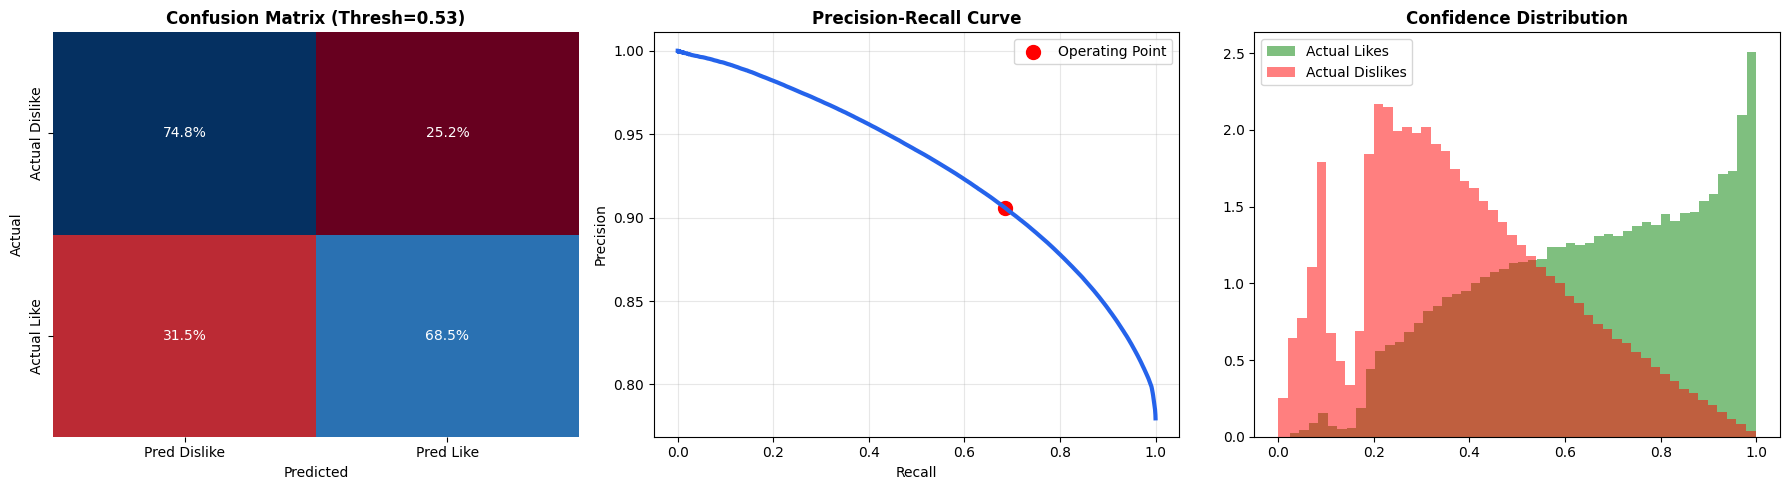

In [ ]:
# Cell 8: Train Optimized Model & Run Final Audit

import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)
import joblib

# Configuration
#OUTPUT_DIR = '/content/drive/MyDrive/imdb_data/ekko_artifacts/models'
FEATURE_NAMES = ['ai_Sim', 'SVD_Score'] # Renamed to match your new file strategy

# Define Best Hyperparameters (From your Optuna Result)
best_params = {
    'n_estimators': 200,             # Increased for final build
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'class_weight': {0: 3.0, 1: 1.0}, # The "Hammer" for Specificity

    # Your Optimized Values
    'num_leaves': 26,
    'learning_rate': 0.19771382945629182,
    'reg_alpha': 0.20088051531284906,
    'reg_lambda': 2.328835722993535e-05,
    'subsample': 0.7986458120655612,
    'colsample_bytree': 0.5068692355785691,
    'min_child_samples': 51
}

print("Training Final Model with Optimized Hyperparameters...")
final_clf = lgb.LGBMClassifier(**best_params)
final_clf.fit(X_train, y_train)

# EVALUATION FUNCTION
def evaluate_production_model(model, X_array, y):
    print(f"\n{'='*50}")
    print(f"EKKO PRODUCTION MODEL AUDIT")
    print(f"{'='*50}")

    X_df = pd.DataFrame(X_array, columns=FEATURE_NAMES)
    probs = model.predict_proba(X_df)[:, 1]

    # Find Optimal Threshold (Maximize Balanced Accuracy)
    fpr, tpr, thresholds = roc_curve(y, probs)
    J = tpr - fpr
    best_thresh = thresholds[np.argmax(J)]
    print(f"Optimal 'Fair' Threshold: {best_thresh:.4f}")

    # Apply Threshold
    preds = (probs >= best_thresh).astype(int)

    # Metrics
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    print(f"\nPERFORMANCE REPORT")
    print(f"{'-'*30}")
    print(f"Recall (Like):         {recall:.4f}  (Captures {recall:.1%} of good movies)")
    print(f"Specificity (Dislike): {specificity:.4f}  (Filters {specificity:.1%} of bad movies)")
    print(f"Precision (Like):      {precision:.4f}  (Trustworthiness: {precision:.1%})")
    print(f"Balanced Accuracy:     {(recall + specificity)/2:.4f}")
    print(f"ROC AUC Score:         {roc_auc_score(y, probs):.4f}")

    # Ranking Quality
    print(f"\nCAROUSEL QUALITY")
    print(f"{'-'*30}")

    def get_top_k(k_pct):
        df = pd.DataFrame({'target': y, 'prob': probs}).sort_values('prob', ascending=False)
        top_k = df.head(int(len(df) * (k_pct / 100)))
        return top_k['target'].mean(), len(top_k)

    p1, c1 = get_top_k(1)
    p5, c5 = get_top_k(5)
    print(f"Top 1% (Hero Banner):  {p1:.2%} accurate (Size: {c1})")
    print(f"Top 5% (Recs Feed):    {p5:.2%} accurate (Size: {c5})")

    # Visualizations
    plt.figure(figsize=(18, 5))

    # Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_norm = confusion_matrix(y, preds).astype('float') / confusion_matrix(y, preds).sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdBu', cbar=False,
                xticklabels=['Pred Dislike', 'Pred Like'], yticklabels=['Actual Dislike', 'Actual Like'])
    plt.title(f'Confusion Matrix (Thresh={best_thresh:.2f})', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Precision-Recall Curve
    plt.subplot(1, 3, 2)
    p, r, _ = precision_recall_curve(y, probs)
    plt.plot(r, p, color='#2563EB', lw=3)
    idx = (np.abs(r - recall)).argmin()
    plt.scatter(r[idx], p[idx], color='red', s=100, label='Operating Point')
    plt.title('Precision-Recall Curve', fontweight='bold')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Confidence Distribution
    plt.subplot(1, 3, 3)
    plt.hist(probs[y==1], bins=50, alpha=0.5, label='Actual Likes', color='green', density=True)
    plt.hist(probs[y==0], bins=50, alpha=0.5, label='Actual Dislikes', color='red', density=True)
    plt.title('Confidence Distribution', fontweight='bold')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run Audit
evaluate_production_model(final_clf, X_test, y_test)

## The model we will implement

In [ ]:
# Cell 8 (Optimization): Find Exact Best n_estimators

import lightgbm as lgb
import matplotlib.pyplot as plt

# Define params (Note: I added colsample_bytree back!)
# You missed 'colsample_bytree' in your snippet - it's crucial for the 50/50 balance!
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'class_weight': {0: 3.0, 1: 1.0},
    'num_leaves': 26,
    'learning_rate': 0.1,
    'reg_alpha': 0.20088,
    'reg_lambda': 2.3288e-05,
    'subsample': 0.7986,
    'colsample_bytree': 0.5068,
    'min_child_samples': 51
}

# Train with Early Stopping
# We set n_estimators=1000, but the 'callbacks' will stop it early.
clf_test = lgb.LGBMClassifier(**params, n_estimators=1000)

print("Training with Early Stopping...")
clf_test.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

print(f"\n🏆 Best Iteration: {clf_test.best_iteration_}")

Training with Early Stopping...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.79221
[100]	valid_0's auc: 0.793069
[150]	valid_0's auc: 0.793171
[200]	valid_0's auc: 0.793181
[250]	valid_0's auc: 0.793182
Early stopping, best iteration is:
[231]	valid_0's auc: 0.793182

🏆 Best Iteration: 231


In [ ]:
# Cell 5: Train LightGBM (Aggressive Dislike Weighting)

print("Training LightGBM with DISLIKE PENALTY... + optuna parameters")

# We define manual weights:
# Class 0 (Dislike): Weight 3.0 (Crucial to get right)
# Class 1 (Like):    Weight 1.0 (Standard)
# This forces the model to prioritize specificity.
custom_weights = {0: 3.0, 1: 1.0}

clf = lgb.LGBMClassifier(
    n_estimators=231,
    random_state=42,
    class_weight=custom_weights,
    objective= 'binary',
    metric= 'auc',
    verbosity= -1,
    boosting_type= 'gbdt',
    # Your Optimized Values by optuna
    num_leaves=26,
    learning_rate=0.1,
    reg_alpha=0.20088051531284906,
    reg_lambda=2.328835722993535e-05,
    colsample_bytree=0.5068,
    subsample=0.7986458120655612,
    min_child_samples=51
)
FEATURE_NAMES = ['ai_Sim', 'SVD_Score']

# Fit
clf.fit(X_train, y_train)

# Evaluate
X_df = pd.DataFrame(X_test, columns=FEATURE_NAMES)
y_pred_prob = clf.predict_proba(X_df)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
acc = accuracy_score(y_test, (y_pred_prob > 0.5).astype(int))

print(f"Training Complete!")
print(f"ROC AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")

# Feature Importance
print("Feature Importance:")
print(f"ai Similarity: {clf.feature_importances_[0]}")
print(f"SVD Score:        {clf.feature_importances_[1]}")

Training LightGBM with DISLIKE PENALTY... + optuna parameters
Training Complete!
ROC AUC: 0.7932
Accuracy: 0.7185
Feature Importance:
ai Similarity: 2900
SVD Score:        2875



EKKO PRODUCTION MODEL AUDIT
Fixed Threshold: 0.5000

PERFORMANCE REPORT
------------------------------
Recall (Like):         0.7210  (Captures 72.1% of good movies)
Specificity (Dislike): 0.7096  (Filters 71.0% of bad movies)
Precision (Like):      0.8978  (Trustworthiness of 'Like')
Balanced Accuracy:     0.7153
ROC AUC Score:         0.7932

CAROUSEL QUALITY (Precision @ Top K)
------------------------------
Top 1% (Hero Banner):  99.88% accurate (Size: 51432)
Top 5% (Recs Feed):    99.53% accurate (Size: 257161)


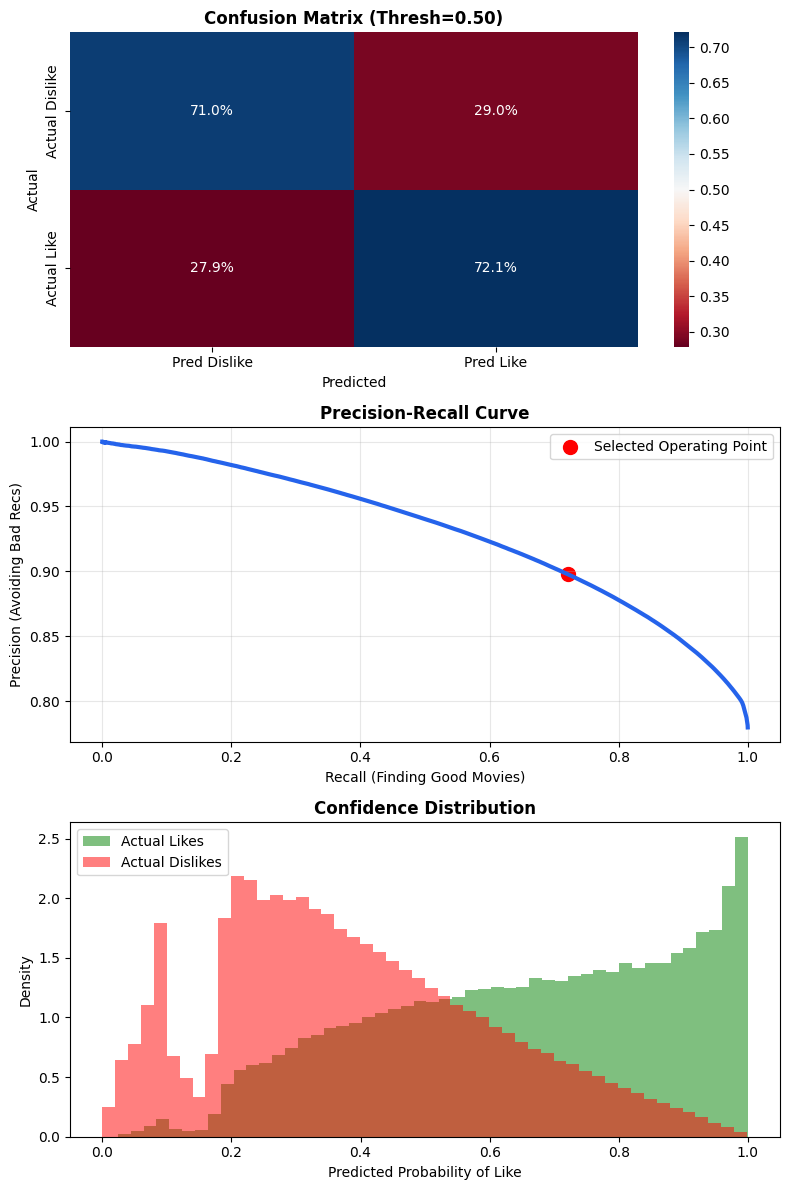

In [ ]:
# Cell 6: The Master Evaluation

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    balanced_accuracy_score
)

FEATURE_NAMES = ['ai_Sim', 'SVD_Score']

def calculate_top_k_precision(y_true, probs, k_percent=5):
    """
    Calculates Precision at Top K% of predictions.
    This answers: "When the model is most confident, is it right?"
    """
    df_eval = pd.DataFrame({'target': y_true, 'prob': probs})
    df_eval = df_eval.sort_values(by='prob', ascending=False)
    top_k_count = int(len(df_eval) * (k_percent / 100))
    top_k_df = df_eval.head(top_k_count)
    return top_k_df['target'].mean(), top_k_count

def evaluate_production_model(model, X_array, y):
    print(f"\n{'='*50}")
    print(f"EKKO PRODUCTION MODEL AUDIT")
    print(f"{'='*50}")

    X_df = pd.DataFrame(X_array, columns=FEATURE_NAMES)
    probs = model.predict_proba(X_df)[:, 1]

#####
    # FIND OPTIMAL THRESHOLD (Youden's J Statistic)
    # We maximize (Recall + Specificity) to treat Dislikes fairly.
    # This fixes the "Positivity Bias" issue.
    #fpr, tpr, thresholds = roc_curve(y, probs)
    #J = tpr - fpr  # J = Sensitivity + Specificity - 1
    #best_idx = np.argmax(J)
    #best_thresh = thresholds[best_idx]

    #print(f"Optimal 'Fair' Threshold: {best_thresh:.4f} (Maximizes Balanced Accuracy)")

    # APPLY THRESHOLD
    #preds = (probs >= best_thresh).astype(int)
#####

    best_thresh = 0.5
    print(f"Fixed Threshold: {best_thresh:.4f}")
    preds = (probs >= best_thresh).astype(int)


    # CORE METRICS
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp) # True Negative Rate
    recall = tp / (tp + fn)      # True Positive Rate
    precision = tp / (tp + fp)   # Positive Predictive Value

    print(f"\nPERFORMANCE REPORT")
    print(f"{'-'*30}")
    print(f"Recall (Like):         {recall:.4f}  (Captures {recall:.1%} of good movies)")
    print(f"Specificity (Dislike): {specificity:.4f}  (Filters {specificity:.1%} of bad movies)")
    print(f"Precision (Like):      {precision:.4f}  (Trustworthiness of 'Like')")
    print(f"Balanced Accuracy:     {(recall + specificity)/2:.4f}")
    print(f"ROC AUC Score:         {roc_auc_score(y, probs):.4f}")

    # RANKING QUALITY (Top-K)
    print(f"\nCAROUSEL QUALITY (Precision @ Top K)")
    print(f"{'-'*30}")
    p_at_1, count_1 = calculate_top_k_precision(y, probs, k_percent=1)
    p_at_5, count_5 = calculate_top_k_precision(y, probs, k_percent=5)
    print(f"Top 1% (Hero Banner):  {p_at_1:.2%} accurate (Size: {count_1})")
    print(f"Top 5% (Recs Feed):    {p_at_5:.2%} accurate (Size: {count_5})")

    # VISUALIZATIONS
    plt.figure(figsize=(8, 12))

    # Plot A: Confusion Matrix (The Truth)
    plt.subplot(3, 1, 1)
    cm = confusion_matrix(y, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdBu',
                xticklabels=['Pred Dislike', 'Pred Like'],
                yticklabels=['Actual Dislike', 'Actual Like'])
    plt.title(f'Confusion Matrix (Thresh={best_thresh:.2f})', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Plot B: Precision-Recall Curve
    plt.subplot(3, 1, 2)
    precisions_pr, recalls_pr, _ = precision_recall_curve(y, probs)
    plt.plot(recalls_pr, precisions_pr, color='#2563EB', lw=3)
    # Plot our chosen point
    # Find the recall on the PR curve closest to our actual recall
    idx_pr = (np.abs(recalls_pr - recall)).argmin()
    plt.scatter(recalls_pr[idx_pr], precisions_pr[idx_pr], color='red', s=100, label='Selected Operating Point')
    plt.title('Precision-Recall Curve', fontweight='bold')
    plt.xlabel('Recall (Finding Good Movies)')
    plt.ylabel('Precision (Avoiding Bad Recs)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot C: Probability Distribution
    plt.subplot(3, 1, 3)
    plt.hist(probs[y==1], bins=50, alpha=0.5, label='Actual Likes', color='green', density=True)
    plt.hist(probs[y==0], bins=50, alpha=0.5, label='Actual Dislikes', color='red', density=True)
    plt.title('Confidence Distribution', fontweight='bold')
    plt.xlabel('Predicted Probability of Like')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the Master Audit
evaluate_production_model(clf, X_test, y_test)

In [ ]:
import joblib

# Configuration
OUTPUT_DIR = '/content/drive/MyDrive/imdb_data/ekko_artifacts/models'

print(f"Saving model to {OUTPUT_DIR}/lightgbm_model.joblib...")
joblib.dump(clf, f'{OUTPUT_DIR}/lightgbm_model.joblib')

Saving model to /content/drive/MyDrive/imdb_data/ekko_artifacts/models/lightgbm_model.joblib...


['/content/drive/MyDrive/imdb_data/ekko_artifacts/models/lightgbm_model.joblib']

# Private Sections For Compariosion Only (heatmap and plot)

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading Metadata and AI Embeddings...
Computing TF-IDF Matrix (this takes a few seconds)...
Calculating similarities for: Interstellar...


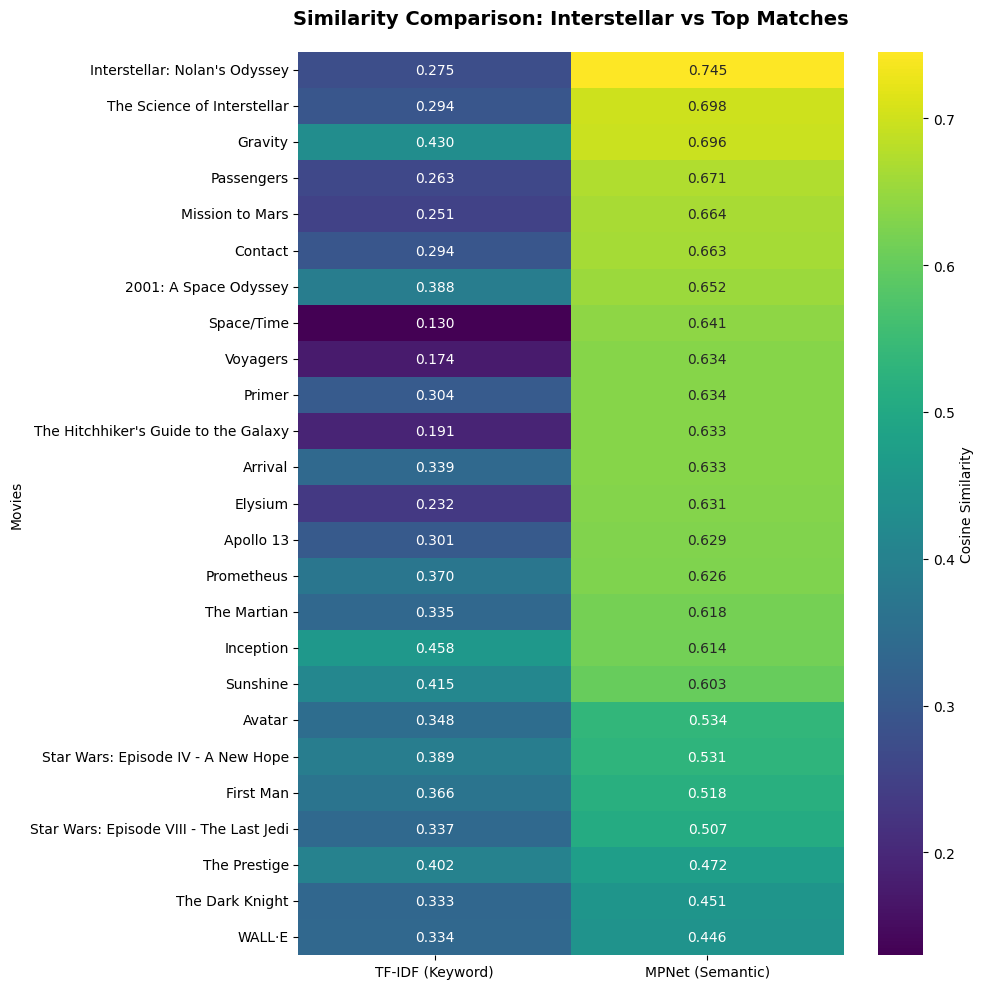

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# LOAD DATA
print("Loading Metadata and AI Embeddings...")
BASE_PATH = '/content/drive/MyDrive/imdb_data/ekko_artifacts'
EMBEDDINGS_PATH = f'{BASE_PATH}/ai_embeddings.npy'
METADATA_PATH = f'{BASE_PATH}/metadata_enriched.parquet'
df_meta = pd.read_parquet(METADATA_PATH).reset_index(drop=True)
ai_emb = np.load(EMBEDDINGS_PATH, mmap_mode='r')

# GENERATE TF-IDF ON THE FLY
# Adjust 'text_blob' to whatever column contains your text data (e.g., 'combined_text')
text_data = df_meta['text_blob'].fillna("")
print("Computing TF-IDF Matrix (this takes a few seconds)...")
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = tfidf_vectorizer.fit_transform(text_data)

# FIND TARGET MOVIE
target_title = 'Interstellar'
try:
    target_idx = df_meta[df_meta['primaryTitle'] == target_title].index[0]
except IndexError:
    raise ValueError(f"Movie '{target_title}' not found in metadata.")

# CALCULATE SIMILARITIES TO ALL MOVIES
print(f"Calculating similarities for: {target_title}...")
target_ai_vec = ai_emb[target_idx].reshape(1, -1)
target_tfidf_vec = tfidf_matrix[target_idx]

sim_ai = cosine_similarity(target_ai_vec, ai_emb).flatten()
sim_tfidf = cosine_similarity(target_tfidf_vec, tfidf_matrix).flatten()

# GET TOP MATCHES FOR HEATMAP
# Get top 10 from AI and top 10 from TF-IDF to compare
top_ai_indices = np.argsort(sim_ai)[-15:][::-1]
top_tfidf_indices = np.argsort(sim_tfidf)[-15:][::-1]

# Combine and get unique indices (removing the target movie itself)
combined_indices = list(set(top_ai_indices).union(set(top_tfidf_indices)))
if target_idx in combined_indices:
    combined_indices.remove(target_idx)

# Prepare DataFrame for Heatmap
heatmap_data = []
titles = []
for idx in combined_indices:
    titles.append(df_meta.iloc[idx]['primaryTitle'])
    heatmap_data.append([sim_tfidf[idx], sim_ai[idx]])

df_heat = pd.DataFrame(heatmap_data, columns=['TF-IDF (Keyword)', 'MPNet (Semantic)'], index=titles)
# Sort by MPNet similarity for a cleaner visual waterfall
df_heat = df_heat.sort_values(by='MPNet (Semantic)', ascending=False)

# text_blob HEATMAP
plt.figure(figsize=(10, 10))
sns.heatmap(df_heat, annot=True, cmap='viridis', fmt='.3f', cbar_kws={'label': 'Cosine Similarity'})
plt.title(f"Similarity Comparison: {target_title} vs Top Matches", pad=20, fontsize=14, fontweight='bold')
plt.ylabel("Movies")
plt.tight_layout()
plt.show()

--- Exact Mathematical Distance ---
Movie A: Interstellar
Movie B: 2001: A Space Odyssey
---------------------------------
TF-IDF Similarity: 0.3877 (Keyword overlap)
MPNet Similarity:  0.6516 (Semantic/Vibe overlap)
---------------------------------


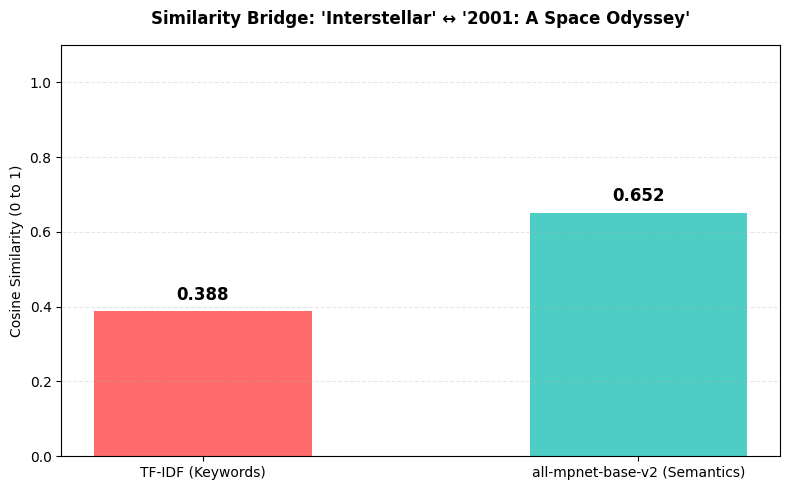

In [ ]:
# Define the two movies to compare
movie_A = 'Interstellar'
movie_B = '2001: A Space Odyssey'

# Find Indices
try:
    idx_A = df_meta[df_meta['primaryTitle'] == movie_A].index[0]
    idx_B = df_meta[df_meta['primaryTitle'] == movie_B].index[0]
except IndexError:
    print(f"Could not find one of the movies. Check exact spelling.")

# Extract Vectors
vec_A_tfidf = tfidf_matrix[idx_A]
vec_B_tfidf = tfidf_matrix[idx_B]

vec_A_ai = ai_emb[idx_A].reshape(1, -1)
vec_B_ai = ai_emb[idx_B].reshape(1, -1)

# Calculate Exact Cosine Similarity
sim_tfidf_exact = cosine_similarity(vec_A_tfidf, vec_B_tfidf)[0][0]
sim_ai_exact = cosine_similarity(vec_A_ai, vec_B_ai)[0][0]

print(f" Exact Mathematical Distance ")
print(f"Movie A: {movie_A}")
print(f"Movie B: {movie_B}")
print("-" * 33)
print(f"TF-IDF Similarity: {sim_tfidf_exact:.4f} (Keyword overlap)")
print(f"MPNet Similarity:  {sim_ai_exact:.4f} (Semantic/Vibe overlap)")
print("-" * 33)

# Visualize the Difference
plt.figure(figsize=(8, 5))
models = ['TF-IDF (Keywords)', 'all-mpnet-base-v2 (Semantics)']
scores = [sim_tfidf_exact, sim_ai_exact]
colors = ['#FF6B6B', '#4ECDC4']

bars = plt.bar(models, scores, color=colors, width=0.5)

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 1.1)
plt.ylabel('Cosine Similarity (0 to 1)')
plt.title(f"Similarity Bridge: '{movie_A}' ↔ '{movie_B}'", pad=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# <font color=Red>**Failed**</font> Compare (Models With Embeddings)
## Due to and the colab ram resources cannot generate Classic tf-idf features for our large datasets
#<font color=Green>**We did create a comparision between the 2 embeddings techniques and it's obvious that the MPNet (semantic coverage) has high results in catching similar titles**</font>

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Paths
BASE_PATH = '/content/drive/MyDrive/imdb_data/ekko_artifacts'
RATINGS_PATH = f'{BASE_PATH}/ratings_labeled.parquet'
EMBEDDINGS_PATH = f'{BASE_PATH}/ai_embeddings.npy'
METADATA_PATH = f'{BASE_PATH}/metadata_enriched.parquet'
OUTPUT_DIR = f'{BASE_PATH}/models'

print("1. Loading Data...")
df_ratings = pd.read_parquet(RATINGS_PATH)
df_meta = pd.read_parquet(METADATA_PATH)

# Load MPNet Embeddings & SVD Factors
mpnet_emb = np.load(EMBEDDINGS_PATH, mmap_mode='r')
svd_factors = np.load(f'{OUTPUT_DIR}/svd_item_factors.npy')

# Create Index Maps
tconst_to_idx = {tconst: idx for idx, tconst in enumerate(df_meta['tconst'])}
df_ratings = df_ratings[df_ratings['tconst'].isin(tconst_to_idx)].copy()
df_ratings['item_idx'] = df_ratings['tconst'].map(tconst_to_idx)

user_ids = df_ratings['userID'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
df_ratings['user_idx'] = df_ratings['userID'].map(user_to_idx)

print("2. Generating TF-IDF Embeddings...")
# We limit to 768 features to match MPNet's dimensionality for a fair comparison
tfidf = TfidfVectorizer(max_features=768, stop_words='english')
# Combine genres and text_blob for TF-IDF
text_data = (df_meta['genres'].fillna('') + " " + df_meta['text_blob'].fillna('')).values
tfidf_emb = tfidf.fit_transform(text_data).toarray().astype(np.float32)

print(" Both Embeddings Ready.")

Mounted at /content/drive
1. Loading Data...
2. Generating TF-IDF Embeddings...
 Both Embeddings Ready.


In [ ]:
print("Splitting Data...")
train_df, test_df = train_test_split(df_ratings, test_size=0.2, random_state=42, stratify=df_ratings['target'])

def build_features(df_subset, embeddings_matrix):
    """Builds [content_sim, svd_score] features for a given embedding matrix."""
    max_user_id = df_ratings['user_idx'].max()
    emb_dim = embeddings_matrix.shape[1]

    # Build User Profiles (Averaging liked items)
    user_profiles = np.zeros((max_user_id + 1, emb_dim), dtype=np.float32)
    likes = train_df[train_df['target'] == 1]
    user_groups = likes.groupby('user_idx')['item_idx'].apply(list)

    for u_idx, item_indices in user_groups.items():
        user_profiles[u_idx] = np.mean(embeddings_matrix[item_indices], axis=0)

    # Generate Features
    u_indices = df_subset['user_idx'].values
    i_indices = df_subset['item_idx'].values
    y_values = df_subset['target'].values

    # Content Similarity
    u_vecs = user_profiles[u_indices]
    i_vecs = embeddings_matrix[i_indices]
    # Normalize on the fly for cosine similarity if not already normalized
    sim_content = np.sum(u_vecs * i_vecs, axis=1) / (np.linalg.norm(u_vecs, axis=1) * np.linalg.norm(i_vecs, axis=1) + 1e-9)

    # SVD Score (Collaborative)
    # Reconstruct user SVD profile based on likes
    user_svd_profiles = np.zeros((max_user_id + 1, 32), dtype=np.float32)
    for u_idx, item_indices in user_groups.items():
        user_svd_profiles[u_idx] = np.mean(svd_factors[item_indices], axis=0)

    u_svd = user_svd_profiles[u_indices]
    i_svd = svd_factors[i_indices]
    score_svd = np.sum(u_svd * i_svd, axis=1)

    X = np.column_stack((sim_content, score_svd))
    return X, y_values

print("Building TF-IDF Features...")
X_train_tfidf, y_train = build_features(train_df, tfidf_emb)
X_test_tfidf, y_test = build_features(test_df, tfidf_emb)

print("Building MPNet Features...")
X_train_mpnet, _ = build_features(train_df, mpnet_emb)
X_test_mpnet, _ = build_features(test_df, mpnet_emb)

print(" Features Built.")

Splitting Data...
Building TF-IDF Features...


In [ ]:
# Scenario Setups
# Untuned Params
params_untuned = {'objective': 'binary', 'random_state': 42, 'verbose': -1}

# Tuned Params (Simulating your tuned LightGBM)
params_tuned = {
    'objective': 'binary',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': 8,
    'min_child_samples': 50,
    'random_state': 42,
    'verbose': -1
}

# Untuned TF-IDF
print("Training Untuned TF-IDF...")
model_untuned_tfidf = lgb.LGBMClassifier(**params_untuned)
model_untuned_tfidf.fit(X_train_tfidf, y_train)
prob_1 = model_untuned_tfidf.predict_proba(X_test_tfidf)[:, 1]

# Untuned MPNet
print("Training Untuned MPNet...")
model_untuned_mpnet = lgb.LGBMClassifier(**params_untuned)
model_untuned_mpnet.fit(X_train_mpnet, y_train)
prob_2 = model_untuned_mpnet.predict_proba(X_test_mpnet)[:, 1]

# Tuned TF-IDF
print("Training Tuned TF-IDF...")
model_tuned_tfidf = lgb.LGBMClassifier(**params_tuned)
model_tuned_tfidf.fit(X_train_tfidf, y_train)
prob_3 = model_tuned_tfidf.predict_proba(X_test_tfidf)[:, 1]

# Tuned MPNet (Loading your saved Final Boss)
print("Loading Saved Tuned MPNet...")
model_tuned_mpnet = joblib.load(f'{OUTPUT_DIR}/lightgbm_model.joblib')
prob_4 = model_tuned_mpnet.predict_proba(X_test_mpnet)[:, 1]

print("Predictions Generated.")

In [ ]:
def plot_distributions(prob_a, name_a, prob_b, name_b, y_true, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Plot A
    sns.kdeplot(prob_a[y_true == 0], fill=True, color='red', label='Dislike (Class 0)', ax=axes[0], alpha=0.5)
    sns.kdeplot(prob_a[y_true == 1], fill=True, color='green', label='Like (Class 1)', ax=axes[0], alpha=0.5)
    axes[0].set_title(f'{name_a}\nAUC: {roc_auc_score(y_true, prob_a):.4f}')
    axes[0].set_xlabel('Predicted Probability of Liking')
    axes[0].legend()

    # Plot B
    sns.kdeplot(prob_b[y_true == 0], fill=True, color='red', label='Dislike (Class 0)', ax=axes[1], alpha=0.5)
    sns.kdeplot(prob_b[y_true == 1], fill=True, color='green', label='Like (Class 1)', ax=axes[1], alpha=0.5)
    axes[1].set_title(f'{name_b}\nAUC: {roc_auc_score(y_true, prob_b):.4f}')
    axes[1].set_xlabel('Predicted Probability of Liking')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Compare 1 vs 2
plot_distributions(
    prob_1, "Scenario 1: Untuned + TF-IDF",
    prob_2, "Scenario 2: Untuned + MPNet",
    y_test,
    "Untuned Models Comparison: TF-IDF vs. MPNet"
)

# Compare 3 vs 4
plot_distributions(
    prob_3, "Scenario 3: Tuned + TF-IDF",
    prob_4, "Scenario 4: Tuned + MPNet (Final Boss)",
    y_test,
    "Tuned Models Comparison: TF-IDF vs. MPNet"
)